# Optuna SQLite Viewer

`optuna_jh.db`의 모든 study와 trial을 DataFrame으로 로드한다.

In [1]:
import os, sys

try:
    import google.colab
    if not os.path.exists("/content/project/setup.py"):
        os.system("pip install -q gdown")
        os.system("gdown --id 1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I -O /content/code.zip")
        os.system("unzip -qo /content/code.zip -d /content/project")
        os.makedirs("/content/project/0_data", exist_ok=True)
        os.system("gdown --id 1yOUo0_wPLcuZBSJIK592b00YkSIlk4zO -O /content/project/0_data/dataset.zip")
        os.system("unzip -qo /content/project/0_data/dataset.zip -d /content/project/0_data")
        os.remove("/content/project/0_data/dataset.zip")
    sys.path.insert(0, "/content/project")
    %run /content/project/setup.py
except ImportError:
    %run ../../setup.py

setup 완료


In [2]:
import optuna
import pandas as pd
from pathlib import Path

optuna.logging.set_verbosity(optuna.logging.WARNING)

DB_PATH = Path("optuna_jh.db").resolve()
STORAGE = f"sqlite:///{DB_PATH.as_posix()}"
print(f"DB: {DB_PATH}")

summaries = optuna.get_all_study_summaries(STORAGE)
study_info = pd.DataFrame([
    {
        "study_name": s.study_name,
        "n_trials": s.n_trials,
        "direction": s.direction.name,
        "best_value": s.best_trial.value if s.best_trial else None,
        "datetime_start": s.datetime_start,
    }
    for s in summaries
])
study_info

DB: C:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\optuna_jh.db


,study_name,n_trials,direction,best_value,datetime_start
0,3-199-004,10,MINIMIZE,0.006223,2026-04-10 17:26:38.120214
1,3-199-005,501,MINIMIZE,0.005658,2026-04-10 21:20:49.466538
2,3-899-001,5,MINIMIZE,0.005564,2026-04-13 14:54:52.098124


In [3]:
# 모든 study의 trial을 하나의 DataFrame으로 합치기
frames = []
for s in summaries:
    study = optuna.load_study(study_name=s.study_name, storage=STORAGE)
    df = study.trials_dataframe()
    df.insert(0, "study_name", s.study_name)
    frames.append(df)

trials_df = pd.concat(frames, ignore_index=True)
print(f"shape: {trials_df.shape}")
trials_df.head()

shape: (516, 62)


,study_name,number,value,datetime_start,datetime_complete,duration,params_clf_colsample_bytree,params_clf_learning_rate,params_clf_max_depth,params_clf_min_child_samples,...,user_attrs_n_feat_selected,user_attrs_outlier_args,user_attrs_saved_at,user_attrs_selected_cols,user_attrs_train_rmse,user_attrs_val_rmse,state,system_attrs_fixed_params,params_pp_post_impute_corr_keep_by,params_pp_post_impute_corr_threshold
0,3-199-004,0,0.006223,2026-04-10 17:26:38.120214,2026-04-10 17:29:03.271247,0 days 00:02:25.151033,0.619465,0.045565,7,37,...,6900,"{'method': 'winsorize', 'lower_pct': 0.01, 'up...",2026-04-10 17:29,"[X1_mean, X4_mean, X5_mean, X6_mean, X7_mean, ...",0.007385,0.006223,COMPLETE,NaN,NaN,NaN
1,3-199-004,1,0.006223,2026-04-10 17:29:03.433201,2026-04-10 17:31:39.110464,0 days 00:02:35.677263,0.423169,0.096037,8,163,...,4188,"{'method': 'winsorize', 'lower_pct': 0.01, 'up...",2026-04-10 17:31,"[X1_mean, X4_mean, X5_mean, X6_mean, X7_mean, ...",0.007385,0.006223,COMPLETE,NaN,NaN,NaN
2,3-199-004,2,0.006223,2026-04-10 17:31:39.263709,2026-04-10 17:34:40.444408,0 days 00:03:01.180699,0.476308,0.049188,3,274,...,5648,"{'method': 'winsorize', 'lower_pct': 0.01, 'up...",2026-04-10 17:34,"[X1_mean, X4_mean, X5_mean, X6_mean, X7_mean, ...",0.007385,0.006223,COMPLETE,NaN,NaN,NaN
3,3-199-004,3,0.006223,2026-04-10 17:34:40.592739,2026-04-10 17:40:06.552647,0 days 00:05:25.959908,0.350840,0.278953,7,158,...,4230,"{'method': 'winsorize', 'lower_pct': 0.01, 'up...",2026-04-10 17:40,"[X0_mean, X4_mean, X5_mean, X6_mean, X7_mean, ...",0.007385,0.006223,COMPLETE,NaN,NaN,NaN
4,3-199-004,4,0.006223,2026-04-10 17:40:06.739470,2026-04-10 17:47:29.826992,0 days 00:07:23.087522,0.135529,0.009487,12,59,...,5656,"{'method': 'winsorize', 'lower_pct': 0.01, 'up...",2026-04-10 17:47,"[X1_mean, X4_mean, X5_mean, X6_mean, X7_mean, ...",0.007385,0.006223,COMPLETE,NaN,NaN,NaN


## 1. 성능순 정렬 (Top-N)

분석할 study를 고르고 objective 값 기준으로 정렬한다.

In [4]:
# 분석 대상 study 선택 (None이면 trial 수가 가장 많은 study)
TARGET_STUDY = None
TOP_N = 20

if TARGET_STUDY is None:
    TARGET_STUDY = study_info.sort_values("n_trials", ascending=False).iloc[0]["study_name"]
print(f"target study: {TARGET_STUDY}")

direction = next(s.direction.name for s in summaries if s.study_name == TARGET_STUDY)
ascending = (direction == "MINIMIZE")

sub = trials_df[(trials_df["study_name"] == TARGET_STUDY) & (trials_df["state"] == "COMPLETE")].copy()
sub_sorted = sub.sort_values("value", ascending=ascending).reset_index(drop=True)

param_cols = [c for c in sub_sorted.columns if c.startswith("params_")]
show_cols = ["number", "value"] + param_cols
print(f"COMPLETE trials: {len(sub_sorted)} | direction: {direction} | params: {len(param_cols)}")
sub_sorted[show_cols].head(TOP_N)

target study: 3-199-005
COMPLETE trials: 501 | direction: MINIMIZE | params: 39


,number,value,params_clf_colsample_bytree,params_clf_learning_rate,params_clf_max_depth,params_clf_min_child_samples,params_clf_min_split_gain,params_clf_n_estimators,params_clf_num_leaves,params_clf_path_smooth,...,params_reg_min_child_samples,params_reg_min_split_gain,params_reg_n_estimators,params_reg_num_leaves,params_reg_path_smooth,params_reg_reg_alpha,params_reg_reg_lambda,params_reg_subsample,params_pp_post_impute_corr_keep_by,params_pp_post_impute_corr_threshold
0,465,0.005658,0.811353,0.014901,11,5,0.020939,2273,216,0.013589,...,258,1.476395e-08,519,244,33.682015,1.436178,0.000152,0.739211,NaN,NaN
1,406,0.005659,0.911544,0.023300,11,18,0.005148,2563,222,4.876487,...,44,6.897694e-08,431,236,31.563397,2.239420,0.000018,0.758329,NaN,NaN
2,420,0.005659,0.898629,0.017159,11,17,0.008502,2614,205,3.897650,...,297,5.796445e-08,267,253,26.535538,1.692854,0.000025,0.797139,NaN,NaN
3,402,0.005659,0.900928,0.022485,11,23,0.005688,2553,230,1.499412,...,39,9.652287e-08,526,234,4.019134,2.973629,0.000010,0.782869,NaN,NaN
4,421,0.005659,0.903164,0.016993,11,16,0.012432,2574,211,5.598267,...,270,3.227434e-08,343,256,35.246348,1.714326,0.000028,0.797077,NaN,NaN
5,419,0.005660,0.895846,0.022171,11,16,0.010230,2625,210,6.496063,...,262,6.947989e-08,337,250,27.076202,3.246810,0.000017,0.783723,NaN,NaN
6,467,0.005660,0.797968,0.015039,11,5,0.012241,2254,215,1.457150,...,247,1.277566e-08,544,247,33.665251,1.306070,0.000307,0.723019,NaN,NaN
7,464,0.005660,0.808911,0.015046,11,5,0.013971,2279,215,1.370792,...,256,1.332363e-08,561,243,33.371393,1.405025,0.000114,0.744305,NaN,NaN
8,462,0.005660,0.867087,0.015054,11,6,0.011798,2243,215,3.323221,...,259,1.440873e-08,557,244,33.839638,1.287634,0.000096,0.746974,NaN,NaN
9,454,0.005660,0.890042,0.017424,11,10,0.024476,2510,208,3.949825,...,268,1.747609e-08,380,256,29.808081,0.604372,0.000036,0.722091,NaN,NaN


## 2. 파라미터 중요도 (fANOVA)

Optuna 내장 importance로 objective에 가장 큰 영향을 준 파라미터를 뽑는다.

In [5]:
from optuna.importance import get_param_importances, FanovaImportanceEvaluator

study = optuna.load_study(study_name=TARGET_STUDY, storage=STORAGE)
importances = get_param_importances(study, evaluator=FanovaImportanceEvaluator(seed=42))
importance_df = (
    pd.DataFrame({"param": list(importances.keys()), "importance": list(importances.values())})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
importance_df

,param,importance
0,clf_colsample_bytree,0.345739
1,clf_max_depth,0.227688
2,clf_min_child_samples,0.184276
3,clf_subsample,0.133301
4,pp_corr_keep_by,0.022353
5,clf_min_split_gain,0.013221
6,clf_learning_rate,0.012928
7,pp_agg_preset_idx,0.008552
8,reg_path_smooth,0.006241
9,pp_missing_threshold,0.004730


## 3. 상위 trial의 파라미터 분포

objective 기준 상위 X% trial에서 각 파라미터가 어떤 값에 몰려 있었는지 요약.

In [6]:
import numpy as np

TOP_PCT = 0.1  # 상위 10%
k = max(1, int(len(sub_sorted) * TOP_PCT))
top = sub_sorted.head(k)
rest = sub_sorted.tail(len(sub_sorted) - k)

rows = []
for col in param_cols:
    pname = col.replace("params_", "")
    t_vals = top[col].dropna()
    r_vals = rest[col].dropna()
    if t_vals.empty:
        continue

    if pd.api.types.is_numeric_dtype(t_vals):
        rows.append({
            "param": pname,
            "dtype": "num",
            "top_mean": t_vals.mean(),
            "top_median": t_vals.median(),
            "top_min": t_vals.min(),
            "top_max": t_vals.max(),
            "rest_median": r_vals.median() if len(r_vals) else np.nan,
            "shift": (t_vals.median() - r_vals.median()) if len(r_vals) else np.nan,
        })
    else:
        mode = t_vals.mode().iloc[0] if len(t_vals) else None
        top_rate = (t_vals == mode).mean()
        rest_rate = (r_vals == mode).mean() if len(r_vals) else np.nan
        rows.append({
            "param": pname,
            "dtype": "cat",
            "top_mean": mode,
            "top_median": f"{top_rate:.1%}",
            "top_min": None,
            "top_max": None,
            "rest_median": f"{rest_rate:.1%}" if len(r_vals) else None,
            "shift": None,
        })

top_param_df = pd.DataFrame(rows)
imp_map = dict(zip(importance_df["param"], importance_df["importance"]))
top_param_df["importance"] = top_param_df["param"].map(imp_map).fillna(0)
top_param_df = top_param_df.sort_values("importance", ascending=False).reset_index(drop=True)
print(f"상위 {TOP_PCT:.0%}: {k} trials / 전체: {len(sub_sorted)}")
top_param_df

상위 10%: 50 trials / 전체: 501


,param,dtype,top_mean,top_median,top_min,top_max,rest_median,shift,importance
0,clf_colsample_bytree,num,0.84989,0.865598,0.764766,0.968659,0.917937,-5.233845e-02,0.345739
1,clf_max_depth,num,10.72,11.0,10,12,11.0,0.000000e+00,0.227688
2,clf_min_child_samples,num,11.94,11.0,5,27,23.0,-1.200000e+01,0.184276
3,clf_subsample,num,0.915834,0.93159,0.800151,0.972628,0.801822,1.297676e-01,0.133301
4,pp_corr_keep_by,cat,std,100.0%,None,None,93.1%,NaN,0.022353
5,clf_min_split_gain,num,0.01785,0.015435,0.002847,0.044719,0.003331,1.210409e-02,0.013221
6,clf_learning_rate,num,0.017009,0.016064,0.012835,0.037308,0.018285,-2.220953e-03,0.012928
7,pp_agg_preset_idx,num,0.44,0.0,0,1,0.0,0.000000e+00,0.008552
8,reg_path_smooth,num,28.267039,33.371191,1.204444,37.656414,5.751933,2.761926e+01,0.006241
9,pp_missing_threshold,num,0.753,0.75,0.75,0.9,0.75,0.000000e+00,0.004730


## 4. 단일 파라미터 상세 (value vs param)

특정 파라미터를 지정해 objective와의 관계를 보고, 값 구간별 평균 성능을 확인한다.

param: pp_spatial_max_dist


,count,mean,median,min,max
params_pp_spatial_max_dist,,,,,
"(0.999, 2.0]",377,0.005669,0.005664,0.005659,0.006223
"(2.0, 3.0]",124,0.005668,0.005663,0.005658,0.005708


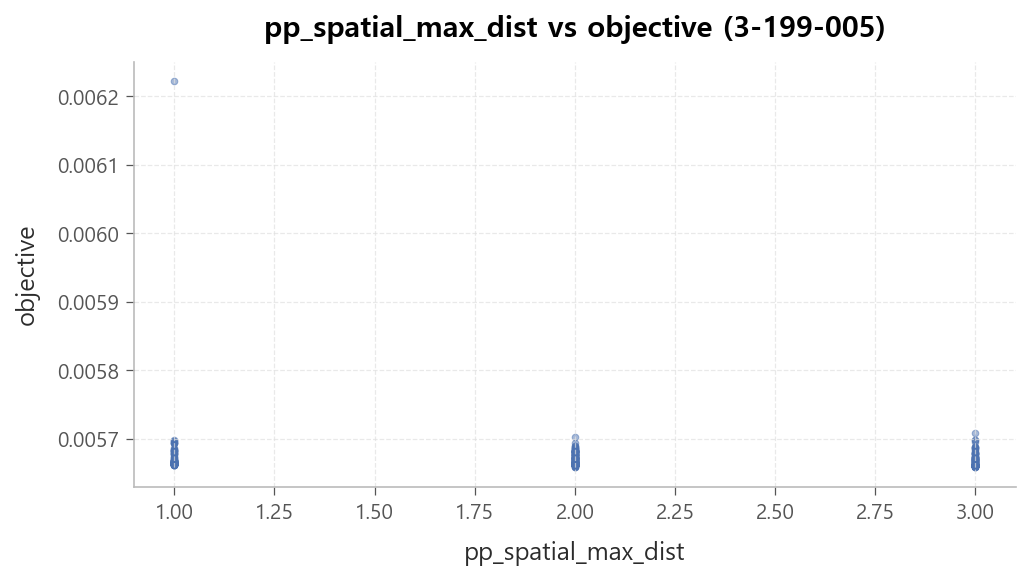

In [9]:
import matplotlib.pyplot as plt

# 보고 싶은 파라미터 — None이면 importance 1위
PARAM = "pp_spatial_max_dist"
if PARAM is None:
    PARAM = importance_df.iloc[0]["param"]
col = f"params_{PARAM}"
print(f"param: {PARAM}")

s = sub_sorted[[col, "value"]].dropna()

if pd.api.types.is_numeric_dtype(s[col]):
    try:
        bins = pd.qcut(s[col], q=10, duplicates="drop")
    except ValueError:
        bins = pd.cut(s[col], bins=10)
    bucket = s.groupby(bins, observed=True)["value"].agg(["count", "mean", "median", "min", "max"])
    display(bucket)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(s[col], s["value"], s=10, alpha=0.5)
    ax.set_xlabel(PARAM); ax.set_ylabel("objective")
    ax.set_title(f"{PARAM} vs objective ({TARGET_STUDY})")
    plt.tight_layout(); plt.show()
else:
    bucket = s.groupby(col, observed=True)["value"].agg(["count", "mean", "median", "min", "max"])
    bucket = bucket.sort_values("mean", ascending=ascending)
    display(bucket)